# Assignment: Is This Patient Sick?
### Understanding Classification & Evaluation Metrics
*Data Science Fundamentals*

---

## The Scenario

You work for a hospital that wants to build an automated screening tool. The tool looks at patient test results (blood pressure, temperature, etc.) and predicts whether the patient is **sick** or **healthy**.

Your job is ***not*** to build the best possible model. Instead, you need to **understand how to evaluate** whether a model is actually doing a good job — and discover why the obvious metric (accuracy) can be dangerously misleading.

> 💡 *You are encouraged to use an LLM (ChatGPT, Claude, etc.) to help you understand the code, explain errors, or explore ideas. Just make sure your written answers are in your own words.*

## Quick Background: The Confusion Matrix

When a classifier makes predictions, every single prediction falls into one of four boxes:

|  | **Predicted: Sick** | **Predicted: Healthy** |
|---|---|---|
| **Actually Sick** | ✅ True Positive (TP) — Correctly caught | ❌ False Negative (FN) — Missed a sick person! |
| **Actually Healthy** | ❌ False Positive (FP) — False alarm | ✅ True Negative (TN) — Correctly cleared |

From these four numbers, we can calculate several useful metrics:

| Metric | Formula | What it tells you |
|---|---|---|
| **Accuracy** | `(TP + TN) / total` | Overall, how often is the model right? |
| **Precision** | `TP / (TP + FP)` | When it says "sick", how often is it actually right? |
| **Recall** | `TP / (TP + FN)` | Of all the truly sick people, how many did it catch? |

---
# Part 1: A First Look (Balanced Data)

Let's start with a nice, balanced dataset: roughly 50% sick, 50% healthy. Run the cell below.

Confusion Matrix:
[[135   9]
 [  8 148]]

Accuracy:  0.943
Precision: 0.943
Recall:    0.949


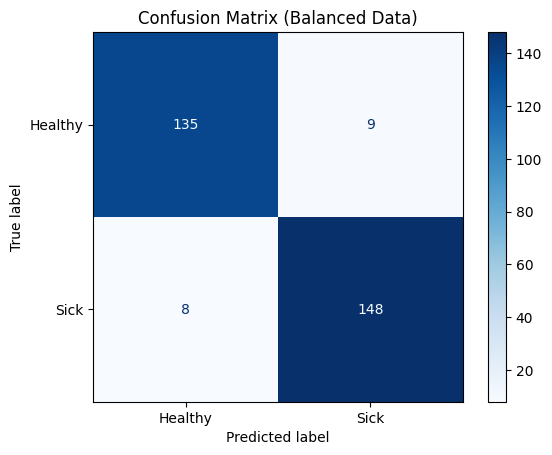

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create a fake patient dataset (balanced: ~50/50 sick vs healthy)
X, y = make_classification(
    n_samples=1000, n_features=5, n_informative=3,
    n_redundant=1, n_classes=2, weights=[0.5, 0.5],
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Print results
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)
print()
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred):.3f}')

# Display the confusion matrix as a visual plot
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Healthy', 'Sick'],
    cmap='Blues'
)
plt.title('Confusion Matrix (Balanced Data)')
plt.show()

> 💡 *The plot shows the same four numbers as the printed matrix, but in a colour-coded grid. The darker the blue, the higher the count. The diagonal (top-left to bottom-right) shows correct predictions.*

### ✏️ Question 1
Run the code above. Look at both the printed matrix and the plot. Write down the values: how many TP, TN, FP, FN did you get?

*(Hint: sklearn puts TN in the top-left and TP in the bottom-right.)*

*Your answer here.*

TP = 148.

TN = 135.

FP = 9.

FN = 8.

### ✏️ Question 2
In plain English, what does each of these four numbers mean in our hospital scenario?

For example: "FN = 12 means the model told 12 sick patients they were healthy."

*Your answer here.*

TP = 148 means the model told 148 sick patients they were actually sick.

TN = 135 means the model told 135 healthy patients they were actually healthy.

FP = 9 means the model told 9 healthy patients they were actually sick.

FN = 8 means the model told 8 sick patients they were actually healthy.

### ✏️ Question 3
Look at the accuracy, precision, and recall. Are they all roughly similar? Why do you think that is, given that the data is balanced (about 50/50)?

*Your answer here.*

The accuracy (94.3%), precision (94.3%), and recall (94.9%) are roughly similar, around 94%.

Since the data is balanced, both classes contribute equally to the evaluation metrics. As a result, false positives and false negatives have a similar impact on performance.

Because the model performs similarly on both classes, precision (TP / (TP + FP)) and recall (TP / (TP + FN)) remain close. Accuracy also falls within the same range, as correct predictions are evenly distributed across both classes.

Overall, this suggests that the model is performing consistently without a strong bias toward either class.


---
# Part 2: The Imbalanced Trap

In reality, most people who get screened are healthy. Let's make the data more realistic: **only 5% of patients are actually sick**.

The code below is the same as Part 1 with **one change** — the `weights` parameter has been changed from `[0.5, 0.5]` to `[0.95, 0.05]`. Run it.

Confusion Matrix:
[[282   3]
 [  6   9]]

Accuracy:  0.970
Precision: 0.750
Recall:    0.600


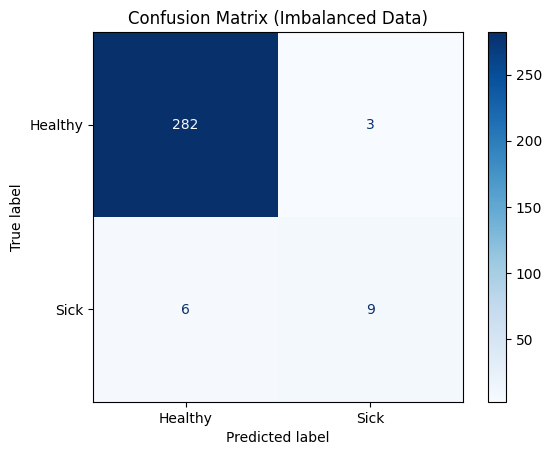

In [2]:
# Same code as Part 1, but now only ~5% of patients are sick
X, y = make_classification(
    n_samples=1000, n_features=5, n_informative=3,
    n_redundant=1, n_classes=2, weights=[0.95, 0.05],  # <-- THIS IS THE ONLY CHANGE
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Print results
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)
print()
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred):.3f}')

# Display the confusion matrix as a visual plot
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Healthy', 'Sick'],
    cmap='Blues'
)
plt.title('Confusion Matrix (Imbalanced Data)')
plt.show()

> 💡 *Look at the confusion matrix plot and compare it to the one from Part 1 — notice how the colour pattern has shifted. Where have all the numbers gone?*

### ✏️ Question 4
What is the accuracy now? Does it look good or bad? Now look at recall — what happened to it? What does that low recall number mean in terms of actual sick patients being missed?

*Your answer here.*

The accuracy ((TP + TN)/Total = 97%) appears very high and suggests good overall performance.

However, the recall (Recall = TP / (TP + FN) = 60%) is relatively low and much lower than in the previous balanced data.

The recall number means out of all actually sick patients, the model only caught 60% of them. The other 40% were missed and told they were healthy (false negatives) which could worsen the condition.

For this imbalanced data, healthy people dominate the dataset, so the high accuracy hides the fact that the model is bad at detecting sick people.

### ✏️ Question 5
Imagine a "lazy model" that just predicts every single patient as healthy (never predicts sick). What would its accuracy be on this dataset? (You can think this through logically — no code needed.) What would its recall be?

*Your answer here.*

For the lazy model, TP = 0, FP = 0, TN = 285, FN = 15.

Accuracy = (TP + TN)/Total = 285/300 = 95%

Recall = TP/(TP + FN) = 0/15 = 0

### ✏️ Question 6
Based on Questions 4 and 5: explain in 2–3 sentences why accuracy alone is a bad metric for this hospital scenario. Which metric matters more here — precision or recall? Why?

*Your answer here.*

Accuracy is misleading in this scenario because the dataset is highly imbalanced, with very few sick patients. A model can achieve high accuracy by simply predicting most patients as healthy, while failing to detect actual sick cases.

In this context, recall is more important because it measures the model’s ability to correctly identify sick patients. Missing a sick patient (false negative) can have serious consequences, making recall the more critical metric.


---
# Part 3: Adjusting the Threshold

Most classifiers don't just output "sick" or "healthy" — they output a **probability** (like "73% chance of being sick"). By default, the cutoff is 50%: if the model says ≥50% chance, it predicts "sick."

But we can **lower that threshold**. If we say "anything above 20% gets flagged as sick," the model will catch more sick people — but also trigger more false alarms.

The code below uses the imbalanced model from Part 2 and tries three different thresholds. Run it.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Use logistic regression to produce smooth probabilities in [0, 1]
reg_model = LogisticRegression(random_state=42, max_iter=1000)
reg_model.fit(X_train, y_train)

# Get probabilities instead of hard predictions
y_probs = reg_model.predict_proba(X_test)[:, 1]

y_probs

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [ ]:
# Try three different thresholds
for threshold in [0.5, 0.3, 0.1]:
    y_pred_t = (y_probs >= threshold).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    print(f'--- Threshold = {threshold} ---')
    print(f'Confusion Matrix:\n{cm_t}')
    print(f'Accuracy:  {accuracy_score(y_test, y_pred_t):.3f}')
    print(f'Precision: {precision_score(y_test, y_pred_t, zero_division=0):.3f}')
    print(f'Recall:    {recall_score(y_test, y_pred_t, zero_division=0):.3f}')
    print()

--- Threshold = 0.5 ---
Confusion Matrix:
[[285   0]
 [  7   8]]
Accuracy:  0.977
Precision: 1.000
Recall:    0.533

--- Threshold = 0.3 ---
Confusion Matrix:
[[285   0]
 [  5  10]]
Accuracy:  0.983
Precision: 1.000
Recall:    0.667

--- Threshold = 0.1 ---
Confusion Matrix:
[[275  10]
 [  3  12]]
Accuracy:  0.957
Precision: 0.545
Recall:    0.800



### ✏️ Question 7
Fill in this table with your results (approximate values are fine):

| Threshold | Accuracy | Precision | Recall |
|-----------|----------|-----------|--------|
| 0.5       |  97.7%   |   100%    |  53.3% |
| 0.3       |  98.3%   |   100%    |  66.7% |
| 0.1       |  95.7%   |   54.5%   |  80%   |

### ✏️ Question 8
As you lower the threshold, what happens to recall? What happens to precision? Why is there a tradeoff between these two?

*Your answer here.*

As the threshold lowers:

(1)The recall increases from 53.3% to 80%, because the model predicts “sick” more easily and captures more actual sick patients (increased TP, decreased FN).

(2)The precision decreases from 100% to 54.5%, because more healthy patients are incorrectly predicted as sick (increased FP).

The tradeoff exists because lowering the threshold makes the model more likely to predict the positive class. As a result, both TP and FP increase. TP boosts recall, while FP reduces precision.

### ✏️ Question 9
If you were the hospital's chief medical officer and had to pick one threshold, which would you choose and why? There's no single right answer — just explain your reasoning.

*(Think about: what's worse, missing a sick patient or sending a healthy patient for extra tests?)*

*Your answer here.*

I would choose the threshold of 0.1 (Recall = 80%).

In this scenario, the cost of false negatives (FN) far outweighs the cost of false positives (FP). Missing a truly sick patient could lead to severe consequences, such as disease progression, transmission to others, or even death. These outcomes are irreversible and critical.

In contrast, false positives are relatively manageable. A healthy patient falsely flagged as “sick” can undergo follow-up testing to confirm the diagnosis, which may incur additional cost and inconvenience but does not cause serious harm.

Therefore, it is preferable to prioritize recall in medical screening contexts. This aligns with standard practice, where initial screening aims to identify as many potential cases as possible, followed by more precise confirmatory tests.

Using higher thresholds such as 0.3 or 0.5 would reduce recall (to 66.7% and 53.3%, respectively), resulting in a substantial number of missed cases. This is generally unacceptable in healthcare settings unless resource constraints are extremely severe.

For these reasons, a threshold of 0.1 represents the safest and most appropriate choice.

---
## Submission

Submit this completed notebook containing:
- Your answers to Questions 1–9 (written in the *Your answer here* cells)
- The output from running each code cell
- The filled-in table from Question 7

> 💡 *Grading emphasis: q1-8 worth 5 points each and q9 worth 10 points. We care much more about your explanations and reasoning than about getting perfect numbers. If something surprises you or doesn't work as expected, write about that — that's great learning.*